In [ ]:
import getpass
import os

password = ""
command = "sudo apt-get install -y -qq glpk-utils" # can be any command but don't forget -S as it enables input from stdin
os.popen(command, 'w').write(password+'\n') 

!pip install pyomo

1357.94s - pydevd: Sending message related to process being replaced timed-out after 5 seconds


Daniel Fuentes Ensuncho: 202210839

Diego Alejandro Pulido: 202215711

In [24]:

import matplotlib.pyplot as plt
from pyomo.environ import *


# Problema 1: Asignación de Tareas en un Equipo de De-sarrollo Ágil

## Parte A

### Problema

Encontrar el mayor número de tareas de alta prioridad que puedan ser completadas en un sprint con los 52 puntos de historia.

### Suposiciones

- Las tareas de más alta prioridad son las que tienen mayor puntaje.
- Las tareas más criticas se deberían resolver primero, por lo que no debería haber una tarea de un puntaje $i$ escogida si hay una tarea de puntaje $i+1$ que no ha sido escogida.
- En este modelo no importa la cantidad de tareas, por ende tampoco la cantidad de desarrolladores, pues se busca maximizar el puntaje total de las tareas escogidas sin sobre pasar los 52 puntos de historia.

### Variables clave

$X_i$ binaria que indica si la tarea $i$ es seleccionada o no. Siendo $i$ el número de la tarea.

### Parámetros

Definimos T como el conjunto de tareas, donde $T = \{1,..,12\}$

El parámetro $S_i$ es el número de puntos que se le asignan a la tarea $i$.

Por otro lado está el parámetro $P_i$ que es la prioridad de la tarea $i$, donde $p_i \in \{1,2,3, 4,5,6,7\}$ con las siguientes asignaciones:

| Prioridad | Valor |
|-----------|-------|
| Mínima    | 1     |
| Baja      | 2     |
| Media baja | 3    |
| Media     | 4     |
| Media alta | 5    |
| Alta      | 6     |
| Máxima    | 7     |

### Función objetivo

$$\max(\sum_{i\ \in \ T} S_i \cdot X_i)$$

### Restricciones

Número máximo de puntos de historia:
$$\sum_{i\in T} S_i \cdot X_i \leq 52$$
Prioridad de las tareas:
$$P_i \geq P_j \quad \forall \ i,j \ | \ X_i = 1 \ \land \ X_j = 0$$

### Tipo de problema

El problema es MIP, pues una de las variables es binaria, y se busca maximizar una función lineal.

### Implementacion

Task 1 is 1.0
Task 2 is 1.0
Task 3 is 1.0
Task 4 is 1.0
Task 5 is 0.0
Task 6 is 1.0
Task 7 is 1.0
Task 8 is 1.0
Task 9 is 1.0
Task 10 is 1.0
Task 11 is 0.0


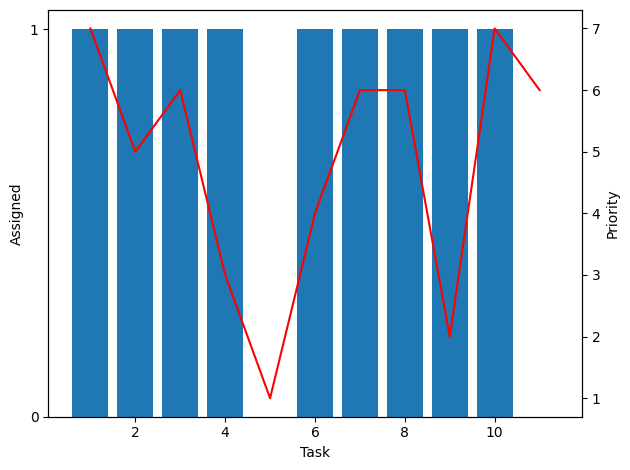

In [25]:
NUM_TASKS = 11
MAX_POINTS = 52

s_i = [5, 3, 13, 1, 21, 2, 2, 5, 8, 13, 21]

priorities = ["Máxima", "Media alta", "Alta", "Media baja", "Mínima", "Media", "Alta", "Alta", "Baja", "Máxima", "Alta"]
prior_val = {
    "Mínima": 1,
    "Baja": 2,
    "Media baja": 3,
    "Media": 4,
    "Media alta": 5,
    "Alta": 6,
    "Máxima": 7
}

p_i = [prior_val[p] for p in priorities]

# Parte A
model = ConcreteModel()
model.i = RangeSet(NUM_TASKS)
model.x = Var(model.i, domain=Binary)
model.obj = Objective(expr=sum(p_i[i-1]*model.x[i] for i in model.i), sense=maximize)
model.rest_num_points = ConstraintList()
model.rest_num_points.add(sum(model.x[i]  * s_i[i-1] for i in model.i) <= MAX_POINTS)

solver = SolverFactory('glpk')
solver.solve(model)

for i in model.i:
    print(f"Task {i} is {model.x[i].value}")

fig, ax1 = plt.subplots()

ax1.bar(range(1, NUM_TASKS+1), [model.x[i].value for i in model.i], label="Assigned")
ax1.set_xlabel('Task')
ax1.set_ylabel('Assigned')
ax1.set_yticks([0, 1])
ax1.tick_params(axis='y')

ax2 = ax1.twinx()
ax2.plot(range(1, NUM_TASKS+1), [p_i[i-1] for i in model.i], 'r', label="Priority")
ax2.set_ylabel('Priority')
ax2.set_yticks(range(1, 8))
ax2.tick_params(axis='y')

fig.tight_layout()
plt.show()

## Parte B

### 13 Puntos por desarrollador

Para este caso tenemos que agregar un nuevo conjunto, $D$, que representan a los desarrolladores, donde $D = \{1,2,3,4\}$

Ahora para la función objetivo, se cuenta con dos índices, $i \in T$ y $j \in D$. Y ahora la variable de decisión es $X_{ij}$, que indica si la tarea $i$ es asignada al desarrollador $j$.

### Función objetivo

$$\max(\sum_{i\ \in \ T} \sum_{j\ \in \ D} S_i \cdot X_{ij})$$

### Restricciones

A demás de las restricciones anteriores, se deben agregar las siguientes:

Cada tarea, puede o no ser asignada, pero no a más de un desarrollador:
$$\sum_{j\ \in \ D} X_{ij} \leq 1 \quad \forall \ i \ \in \ T$$

El número de puntos de historia asignados a cada desarrollador no puede exceder 13:
$$\sum_{j\ \in \ D} X_{ij} \cdot S_i = 13 \quad \forall \ i \ \in \ T$$

### Implementacion

Task 1 is assigned to developer 1
Task 2 is assigned to developer 1
Task 8 is assigned to developer 1
Task 10 is assigned to developer 2
Task 3 is assigned to developer 3
Task 4 is assigned to developer 4
Task 6 is assigned to developer 4
Task 7 is assigned to developer 4
Task 9 is assigned to developer 4


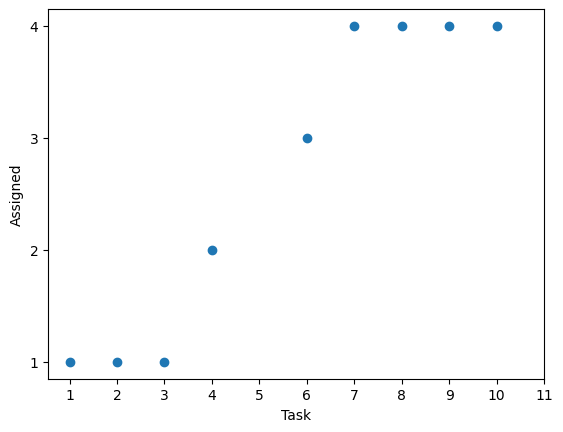

In [26]:
NUM_DEVS = 4
MAX_DEV_POINTS = 13

model = ConcreteModel()
model.i = RangeSet(NUM_TASKS)
model.j = RangeSet(NUM_DEVS)
model.x = Var(model.i, model.j, domain=Binary)
model.obj = Objective(expr=sum(p_i[i-1]*model.x[i,j] for i in model.i for j in model.j), sense=maximize)
model.rest_num_points = ConstraintList()
model.rest_task_per_dev = ConstraintList()

for j in model.j:
    model.rest_num_points.add(sum(model.x[i,j] * s_i[i-1] for i in model.i) <= MAX_DEV_POINTS)

for i in model.i:
    model.rest_task_per_dev.add(sum(model.x[i,j] for j in model.j) <= 1)

solver = SolverFactory('glpk')
solver.solve(model)

for j in model.j:
    for i in model.i:
        if model.x[i,j].value == 1:
            print(f"Task {i} is assigned to developer {j}")


fig, ax1 = plt.subplots()

ax1.scatter([i for i in model.i for j in model.j if model.x[i,j].value == 1], [j for j in model.j for i in model.i if model.x[i,j].value == 1], label="Assigned")

ax1.set_xlabel('Task')
ax1.set_ylabel('Assigned')

ax1.set_yticks(range(1, NUM_DEVS+1))
ax1.set_xticks(range(1, NUM_TASKS+1))


plt.show()

#Problema 2


##Parte A

### Problema


El problema consiste en asignar trabajos a un equipo de tres trabajadores para maximizar la ganancia total obtenida por cada trabajo completado, sin superar la disponibilidad de horas de cada trabajador.

### Suposiciones

1. Cada trabajo puede ser asignado a un solo trabajador.
2. Cada trabajador tiene una disponibilidad horaria máxima y no puede excederla.
3. No todos los trabajos tienen que ser asignados.
4. Todos los trabajadores pueden realizar cualquier trabajo.


### Variables clave


- **Conjuntos:**
  - \( T \) : Conjunto de trabajos.  T = \{1,2,3,4,5\} \
  - \( W \) : Conjunto de trabajadores.  W = \{1,2,3\} \
- **Índices:**
  - $i \ | \ i \in W$
  - $k \ | \ k \in T$

- **Variable de decisión:**  
  - $x_{ik}$: Variable binaria que indica si el trabajo k es asignado al trabajador i (1) o de lo contrario (0)

- **Dominio de las variables:**
  - $x_{ik} \in \{0,1\} \quad ∀ \ i, k \ \ | \ i \in W \ \land \ k \in T $

### Parámetros

- $ g_k $ : Ganancia obtenida por completar el trabajo $k$, donde $k \in T $.
- $ h_k $ : Tiempo requerido para completar el trabajo $ k $, donde $ k \in T $.
- $ c_i $ : Horas disponibles del trabajador $ i $, donde $ i \in W $.

### Función objetivo


Maximizar la ganancia total de los trabajos asignados:

$$
\max (\sum_{k \ \in \ T} \ \sum_{i \ \in \ W} g_k ⋅ x_{ik})
$$

### Restricciones

1. **Cada trabajo debe ser asignado a un o ningún trabajador**:

   $$
   \sum_{i \in W} x_{ik} \leq 1, \quad \forall \ k \in T
   $$

2. **Restricción de disponibilidad horaria de los trabajadores**:

   $$
   \sum_{k \ \in \ T} h_k ⋅ x_{ik} \leq C_i, \quad \forall \ i \in W
   $$

### Tipo de problema


El problema es un MIP porque la variable de decisión es binaria y se busca maximizar la función. Además que tanto la función como las restricciones son lineales.

### Implementacion


In [27]:
!apt-get install -y glpk-utils

1365.33s - pydevd: Sending message related to process being replaced timed-out after 5 seconds


E: Could not open lock file /var/lib/dpkg/lock-frontend - open (13: Permission denied)
E: Unable to acquire the dpkg frontend lock (/var/lib/dpkg/lock-frontend), are you root?


Ganancia total obtenida: 250.0

Tiempo total utilizado: 20.0 horas
Trabajador 1 realiza el Trabajo 1 (Horas: 4)
Trabajador 1 realiza el Trabajo 5 (Horas: 2)
Trabajador 2 realiza el Trabajo 2 (Horas: 5)
Trabajador 2 realiza el Trabajo 3 (Horas: 3)
Trabajador 3 realiza el Trabajo 4 (Horas: 6)


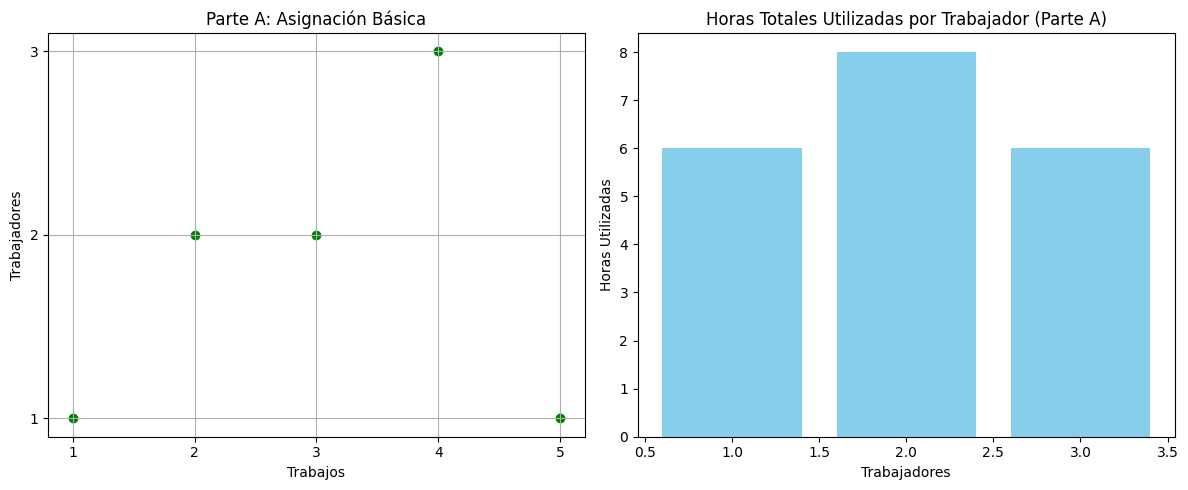

In [28]:
from pyomo.environ import *
import matplotlib.pyplot as plt
import numpy as np

# Datos
trabajadores = [1, 2, 3]
trabajos = [1, 2, 3, 4, 5]

# Ganancia por trabajo
g = {1: 50, 2: 60, 3: 40, 4: 70, 5: 30}
# Horas requeridas por trabajo
h = {1: 4, 2: 5, 3: 3, 4: 6, 5: 2}
# Horas disponibles por trabajador
C = {1: 8, 2: 10, 3: 6}

model_A = ConcreteModel()

# Conjuntos
model_A.W = Set(initialize=trabajadores)
model_A.T = Set(initialize=trabajos)

# Variable de decisión
model_A.x = Var(model_A.W, model_A.T, domain=Binary)

# Función objetivo
def objective_rule_A(model):
    return sum(g[k] * model.x[i, k] for i in model.W for k in model.T)

model_A.obj = Objective(rule=objective_rule_A, sense=maximize)

# Restricción: Asignación única
model_A.assignment_constraint = ConstraintList()
for k in model_A.T:
    model_A.assignment_constraint.add(sum(model_A.x[i, k] for i in model_A.W) <= 1)

# Restricción de disponibilidad horaria
for i in model_A.W:
    model_A.assignment_constraint.add(
        sum(h[k] * model_A.x[i, k] for k in model_A.T) <= C[i]
    )

# Solución del modelo A
solver = SolverFactory('glpk', executable='/usr/bin/glpsol')
solver.solve(model_A)

tiempo_total_utilizado_A = sum(h[k] * model_A.x[i, k].value for i in model_A.W for k in model_A.T)

# Resultados Parte A
print("Ganancia total obtenida:", model_A.obj())
print(f"\nTiempo total utilizado: {tiempo_total_utilizado_A} horas")
for i in model_A.W:
    for k in model_A.T:
        if model_A.x[i, k].value == 1:
            print(f"Trabajador {i} realiza el Trabajo {k} (Horas: {h[k]})")

fig, axs = plt.subplots(1, 2, figsize=(12, 5))

# Gráfico de Asignación (Parte A)
assignments_A = [(i, k) for i in model_A.W for k in model_A.T if model_A.x[i, k].value == 1]
for i, k in assignments_A:
    axs[0].scatter(k, i, color='green')
axs[0].set_title('Parte A: Asignación Básica')
axs[0].set_xlabel('Trabajos')
axs[0].set_ylabel('Trabajadores')
axs[0].set_xticks(trabajos)
axs[0].set_yticks(trabajadores)
axs[0].grid(True)

# Gráfico de Barras: Horas utilizadas por trabajador (Parte A)
horas_por_trabajador = [sum(h[k] * model_A.x[i, k].value for k in model_A.T) for i in model_A.W]
axs[1].bar(trabajadores, horas_por_trabajador, color='skyblue')
axs[1].set_xlabel("Trabajadores")
axs[1].set_ylabel("Horas Utilizadas")
axs[1].set_title("Horas Totales Utilizadas por Trabajador (Parte A)")

plt.tight_layout()
plt.show()

##Parte B

### Problema

El problema consiste en asignar trabajos a un equipo de tres trabajadores para maximizar la ganancia total obtenida por cada trabajo completado, sin superar la disponibilidad de horas de cada trabajador. Con la condición de que solo el trabajador 1 puede hacer el trabajo 1 y que el trabajador 2 no puede hacer el trabajo 3

### Suposiciones

1. Cada trabajo puede ser asignado a un solo trabajador teniendo en cuenta las excepciones mencionadas
2. Cada trabajador tiene una disponibilidad horaria máxima y no puede excederla.
3. No todos los trabajos tienen que ser asignados.

### Variables clave

- **Conjuntos:**
  - \( T \) : Conjunto de trabajos.  T = \{1,2,3,4,5\} \
  - \( W \) : Conjunto de trabajadores.  W = \{1,2,3\} \
- **Índices:**
  - $i \ | \ i \in W$
  - $k \ | \ k \in T$

- **Variable de decisión:**  
  - $x_{ik}$: Variable binaria que indica si el trabajo k es asignado al trabajador i (1) o de lo contrario (0)

- **Dominio de las variables:**
  - $x_{ik} \in \{0,1\} \quad ∀ \ i, k \ \ | \ i \in W \ \land \ k \in T $

### Parámetros

- $ g_k $ : Ganancia obtenida por completar el trabajo $k$, donde $k \in T $.
- $ h_k $ : Tiempo requerido para completar el trabajo $ k $, donde $ k \in T $.
- $ c_i $ : Horas disponibles del trabajador $ i $, donde $ i \in W $.

### Función objetivo

Maximizar la ganancia total de los trabajos asignados:

$$
\max (\sum_{k \ \in \ T} \ \sum_{i \ \in \ W} g_k ⋅ x_{ik})
$$

### Restricciones

1. **Restricción de disponibilidad horaria de los trabajadores**:

   $$
   \sum_{k \ \in \ T} h_k ⋅ x_{ik} \leq C_i, \quad \forall \ i \in W
   $$

2. **Solo el trabajador 1 puede hacer el trabajo 1**

$$
\sum_{ i \ \in \ W \ | \ i \neq 1} x_{i1} = 0
$$

3. **El trabajador 2 no puede hacer el trabajo 3**

$$
x_{23} = 0
$$


### Tipo de problema

El problema es un MIP porque la variable de decisión es binaria y se busca maximizar la función. Además que tanto la función como las restricciones son lineales.

### Implementacion


--- Parte B: Asignación con Restricciones Adicionales ---
Ganancia total obtenida: 250.0
Trabajador 1 realiza el Trabajo 1 (Horas: 4)
Trabajador 1 realiza el Trabajo 3 (Horas: 3)
Trabajador 2 realiza el Trabajo 2 (Horas: 5)
Trabajador 2 realiza el Trabajo 5 (Horas: 2)
Trabajador 3 realiza el Trabajo 4 (Horas: 6)


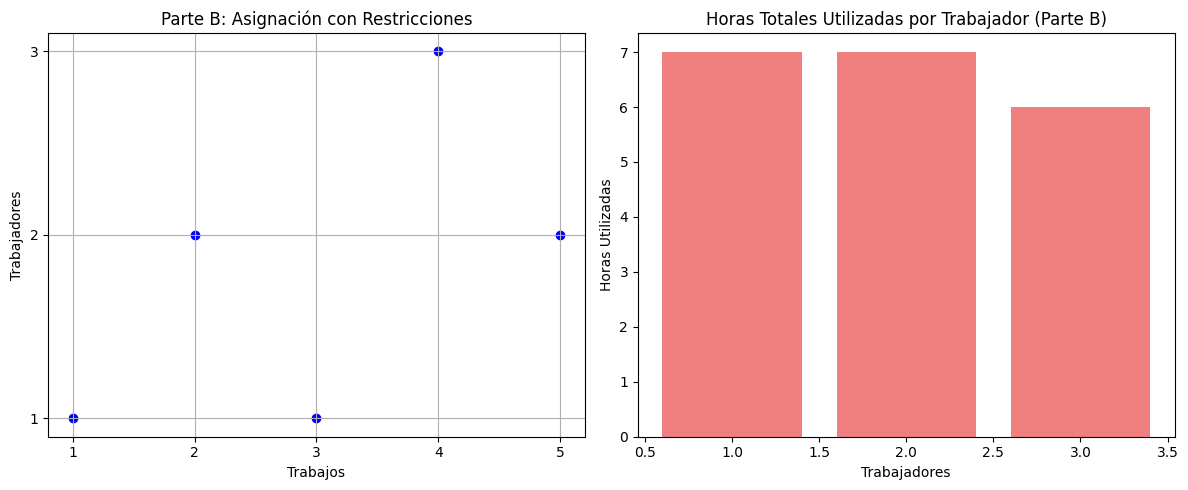

In [29]:
model_B = ConcreteModel()

# Conjuntos
model_B.W = Set(initialize=trabajadores)
model_B.T = Set(initialize=trabajos)

# Variables de decisión
model_B.x = Var(model_B.W, model_B.T, domain=Binary)

# Función objetivo: maximizar la ganancia total
def objective_rule_B(model):
    return sum(g[k] * model.x[i, k] for i in model.W for k in model.T)
model_B.obj = Objective(rule=objective_rule_B, sense=maximize)

# Restricción de asignación única
model_B.assignment_constraint = ConstraintList()
for k in model_B.T:
    model_B.assignment_constraint.add(
        sum(model_B.x[i, k] for i in model_B.W) <= 1
    )

# Restricción de disponibilidad horaria
for i in model_B.W:
    model_B.assignment_constraint.add(
        sum(h[k] * model_B.x[i, k] for k in model_B.T) <= C[i]
    )

# Restricciones adicionales
# Solo el trabajador 1 puede realizar el Trabajo 1
for i in model_B.W:
    if i != 1:
        model_B.assignment_constraint.add(model_B.x[i, 1] == 0)

# El Trabajo 3 no puede ser realizado por el trabajador 2
model_B.assignment_constraint.add(model_B.x[2, 3] == 0)

# Solución del modelo B
solver.solve(model_B)

# Resultados Parte B
print("\n--- Parte B: Asignación con Restricciones Adicionales ---")
print("Ganancia total obtenida:", model_B.obj())
for i in model_B.W:
    for k in model_B.T:
        if model_B.x[i, k].value == 1:
            print(f"Trabajador {i} realiza el Trabajo {k} (Horas: {h[k]})")

figb, axsb = plt.subplots(1, 2, figsize=(12, 5))

# Parte B - Scatter
assignments_B = [(i, k) for i in model_B.W for k in model_B.T if model_B.x[i, k].value == 1]
for i, k in assignments_B:
    axsb[0].scatter(k, i, color='blue')
axsb[0].set_title('Parte B: Asignación con Restricciones')
axsb[0].set_xlabel('Trabajos')
axsb[0].set_ylabel('Trabajadores')
axsb[0].set_xticks(trabajos)
axsb[0].set_yticks(trabajadores)
axsb[0].grid(True)

# Parte B - Barras
horas_por_trabajador_B = [sum(h[k] * model_B.x[i, k].value for k in model_B.T) for i in model_B.W]
axsb[1].bar(trabajadores, horas_por_trabajador_B, color='lightcoral')
axsb[1].set_xlabel("Trabajadores")
axsb[1].set_ylabel("Horas Utilizadas")
axsb[1].set_title("Horas Totales Utilizadas por Trabajador (Parte B)")

plt.tight_layout()
plt.show()


## Diferencia entre PARTE A y PARTE B

|Item |Parte A | Parte B |
|---------|--------|---------|
|Ganancia total|250|250|
|Tiempo total(horas)| 20| 20|
|Distribución|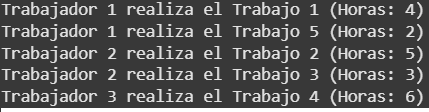|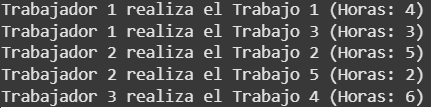|

# Problema 3: Misión Humanitaria en Zambia

### Identifique claramente cuál es el problema que se necesita resolver

Encontrar la mejor manera de distribuir los recursos maximizando el valor de los recursos escogidos para enviar.

### Suposiciones

- Se busca maximizar el valor de los recursos escogidos.
- Cada recurso puede ser enviado por solo uno de los aviones.
- Pueden haber recursos que no sean enviados con tal de que los enviados maximicen el valor total.

### Variables clave

Se proponen los índices $i \in R$ y $j \in A$, donde $R$ es el conjunto de recursos y $A$ el conjunto de aviones.

El conjunto de recursos está relacionado a cada uno de los índices de la siguiente manera:

| Recurso   | Índice     |
|-----------|------------|
| Alimentos básicos | 1  |
| Medicinas         | 2  |
| Equipos médicos   | 3  |
| Agua potable      | 4  |
| Mantas            | 5  |


La variable de decisión es $X_{ij}$, que indica si el recurso $i$ es enviado por el avión $j$.

### Parámetros

- $V_i$ es el valor del recurso $i$.
- $W_i$ es el peso del recurso $i$.
- $M_i$ es el volumen del recurso $i$.

- $C_j$ es la capacidad de peso del avión $j$.
- $D_j$ es la capacidad de volumen del avión $j$.

### Función objetivo

$$\max(\sum_{i\ \in \ R} \sum_{j\ \in \ A} V_i \cdot X_{ij})$$

### Restricciones

El peso total de los recursos enviados por cada avión no puede exceder la capacidad de peso del avión:
$$\sum_{i\ \in \ R} W_i \cdot X_{ij} \leq C_j \quad \forall \ j \ \in \ A$$
El volumen total de los recursos enviados por cada avión no puede exceder la capacidad de volumen del avión:
$$\sum_{i\ \in \ R} M_i \cdot X_{ij} \leq D_j \quad \forall \ j \ \in \ A$$
Un recurso no puede ser enviado por más de un avión:
$$\sum_{j\ \in \ A} X_{ij} \leq 1 \quad \forall \ i \ \in \ R$$
El avión 1 no puede llevar medicamentos:
$$ X_{2,1} = 0$$
Los equipos médicos y el agua potable no deben ser enviados por el mismo avión:
$$ X_{3,j} \neq X_{4,j} \quad \forall \ j \ \in \ A$$

### Tipo de problema

El problema es LP, pues las variables de peso y volumen son reales, y se busca maximizar una función lineal.

### Implementacion

--- Asignación de Recursos ---
Valor total transportado: 370.0
Recurso 1 asignado al Avión 1
Recurso 2 asignado al Avión 2
Recurso 3 asignado al Avión 3
Recurso 4 asignado al Avión 2
Recurso 5 asignado al Avión 2


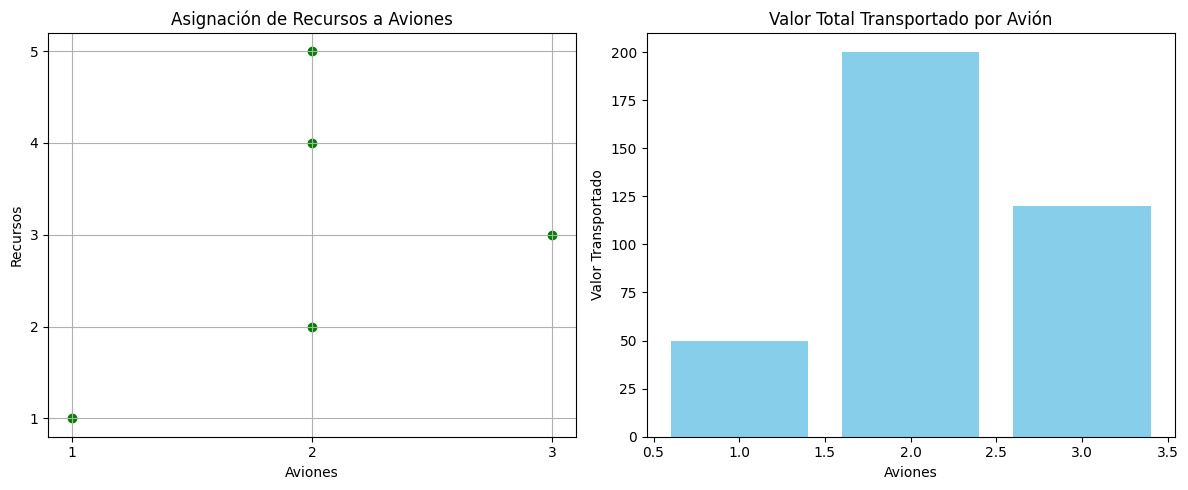

In [30]:
from pyomo.environ import *
import matplotlib.pyplot as plt

recursos = [1, 2, 3, 4, 5]  # 1: Alimentos, 2: Medicinas, 3: Equipos Médicos, 4: Agua, 5: Mantas
aviones = [1, 2, 3]

# Parámetros
# Valor recurso
valor = {1: 50, 2: 100, 3: 120, 4: 60, 5: 40}
# Peso recurso
peso = {1: 15, 2: 5, 3: 20, 4: 18, 5: 10}
#Volumen recurso
volumen = {1: 8, 2: 2, 3: 10, 4: 12, 5: 6}

capacidad_peso = {1: 30, 2: 40, 3: 50}
capacidad_volumen = {1: 25, 2: 30, 3: 35}

model = ConcreteModel()

# Conjuntos
model.R = Set(initialize=recursos)
model.A = Set(initialize=aviones)

# Variable decision
model.X = Var(model.R, model.A, domain=Binary)

# Función Objetivo
def objective_rule(model):
    return sum(valor[i] * model.X[i, j] for i in model.R for j in model.A)
model.obj = Objective(rule=objective_rule, sense=maximize)

# Restricciones
# Capacidad de Peso
model.peso_constraint = ConstraintList()
for j in model.A:
    model.peso_constraint.add(
        sum(peso[i] * model.X[i, j] for i in model.R) <= capacidad_peso[j]
    )

# Capacidad de Volumen
model.volumen_constraint = ConstraintList()
for j in model.A:
    model.volumen_constraint.add(
        sum(volumen[i] * model.X[i, j] for i in model.R) <= capacidad_volumen[j]
    )

# Asignación Única (cada recurso solo en un avión)
model.asignacion_unica = ConstraintList()
for i in model.R:
    model.asignacion_unica.add(
        sum(model.X[i, j] for j in model.A) <= 1
    )

# 4. Medicinas NO en Avión 1
model.medicina_restriccion = Constraint(expr=model.X[2, 1] == 0)

# 5. Equipos Médicos y Agua NO en el mismo avión
model.compatibilidad_restriccion = ConstraintList()
for j in model.A:
    model.compatibilidad_restriccion.add(
        model.X[3, j] + model.X[4, j] <= 1
    )

solver = SolverFactory('glpk')
solver.solve(model)

print("--- Asignación de Recursos ---")
print("Valor total transportado:", model.obj())
for i in model.R:
    for j in model.A:
        if model.X[i, j].value == 1:
            print(f"Recurso {i} asignado al Avión {j}")

fig, axs = plt.subplots(1, 2, figsize=(12, 5))

asignaciones = [(i, j) for i in model.R for j in model.A if model.X[i, j].value == 1]
for i, j in asignaciones:
    axs[0].scatter(j, i, color='green')
axs[0].set_title('Asignación de Recursos a Aviones')
axs[0].set_xlabel('Aviones')
axs[0].set_ylabel('Recursos')
axs[0].set_xticks(aviones)
axs[0].set_yticks(recursos)
axs[0].grid(True)

valor_por_avion = [sum(valor[i] * model.X[i, j].value for i in model.R) for j in model.A]
axs[1].bar(aviones, valor_por_avion, color='skyblue')
axs[1].set_xlabel('Aviones')
axs[1].set_ylabel('Valor Transportado')
axs[1].set_title('Valor Total Transportado por Avión')

plt.tight_layout()
plt.show()